In [1]:
pip install transformers torch scikit-learn pandas numpy seaborn matplotlib

In [2]:
import pandas as pd
import numpy as np
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import DataLoader, TensorDataset
import seaborn as sns
import matplotlib.pyplot as plt

print("All imports successful!")

All imports successful!


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import zipfile

z = zipfile.ZipFile('/content/drive/MyDrive/Sentiment Analysis Dataset.zip')

train_df = pd.read_csv(z.open('Sentiment Analysis Dataset/train.csv'), encoding='latin-1')
test_df = pd.read_csv(z.open('Sentiment Analysis Dataset/test.csv'), encoding='latin-1')

print(train_df.shape)
print(test_df.shape)
print(train_df.columns.tolist())

(27481, 9)
(4815, 9)
['textID', 'text', 'sentiment', 'Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']


In [8]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

sample = tokenizer("I love this product!", padding=True, truncation=True, max_length=128)
print(sample)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

{'input_ids': [101, 1045, 2293, 2023, 4031, 999, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}


In [9]:
train_df = train_df.dropna(subset=['text', 'sentiment'])
test_df = test_df.dropna(subset=['text'])

train_df['text'] = train_df['text'].astype(str)
test_df['text'] = test_df['text'].astype(str)

print("Cleaning done!")
print(train_df['sentiment'].value_counts())

Cleaning done!
sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64


In [10]:
le = LabelEncoder()
y_encoded = le.fit_transform(train_df['sentiment'])

print("Classes:", le.classes_)

Classes: ['negative' 'neutral' 'positive']


In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    train_df['text'], y_encoded,
    test_size=0.1, random_state=42, stratify=y_encoded
)

X_test = test_df['text']

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 24732 | Val: 2748 | Test: 3534


In [12]:
def tokenize_data(texts):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )

print("Tokenizing train...")
train_enc = tokenize_data(X_train)

print("Tokenizing val...")
val_enc = tokenize_data(X_val)

print("Tokenizing test...")
test_enc = tokenize_data(X_test)

print("Tokenization done!")

Tokenizing train...
Tokenizing val...
Tokenizing test...
Tokenization done!


In [13]:
train_dataset = TensorDataset(
    train_enc['input_ids'],
    train_enc['attention_mask'],
    torch.tensor(y_train)
)

val_dataset = TensorDataset(
    val_enc['input_ids'],
    val_enc['attention_mask'],
    torch.tensor(y_val)
)

test_dataset = TensorDataset(
    test_enc['input_ids'],
    test_enc['attention_mask']
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print("DataLoaders ready!")

DataLoaders ready!


In [14]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

model = model.to(device)
print("Model loaded!")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using: cuda
Model loaded!


In [15]:
optimizer = AdamW(model.parameters(), lr=2e-5)
EPOCHS = 3

train_losses = []
val_accs = []
best_val_acc = 0

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in train_loader:
        input_ids      = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels         = batch[2].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)


    model.eval()
    val_preds = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch[0].to(device)
            attention_mask = batch[1].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            val_preds.extend(preds.cpu().numpy())

    val_acc = accuracy_score(y_val, val_preds)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")


    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save_pretrained("best_model")
        tokenizer.save_pretrained("best_model")
        print(f"  -> saved new best model (val acc {val_acc:.4f})")

print(f"Training complete! Best val accuracy: {best_val_acc:.4f}")

Epoch 1/3 | Loss: 0.5879 | Val Acc: 0.7911


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  -> saved new best model (val acc 0.7911)
Epoch 2/3 | Loss: 0.4279 | Val Acc: 0.7893
Epoch 3/3 | Loss: 0.3026 | Val Acc: 0.7620
Training complete! Best val accuracy: 0.7911


In [16]:
print(model)
print(f"\nTotal Parameters: {sum(p.numel() for p in model.parameters()):,}")

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


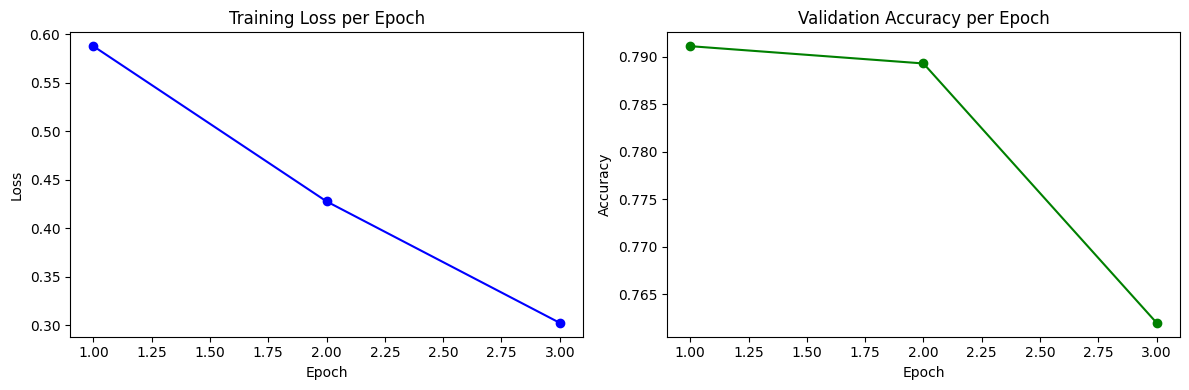

In [17]:
epochs = list(range(1, EPOCHS + 1))
losses = train_losses
val_accs_plot = val_accs

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

ax1.plot(epochs, losses, marker='o', color='blue')
ax1.set_title('Training Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(epochs, val_accs_plot, marker='o', color='green')
ax2.set_title('Validation Accuracy per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

In [18]:

model = DistilBertForSequenceClassification.from_pretrained("best_model").to(device)
model.eval()

test_preds = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch[0].to(device)
        attention_mask = batch[1].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        test_preds.extend(preds.cpu().numpy())

print("Predictions done!")
print(f"Total predictions: {len(test_preds)}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Predictions done!
Total predictions: 3534


Accuracy: 0.7908885116015846

Classification Report:
              precision    recall  f1-score   support

    negative       0.78      0.81      0.79      1001
     neutral       0.77      0.74      0.76      1430
    positive       0.84      0.83      0.83      1103

    accuracy                           0.79      3534
   macro avg       0.79      0.80      0.79      3534
weighted avg       0.79      0.79      0.79      3534



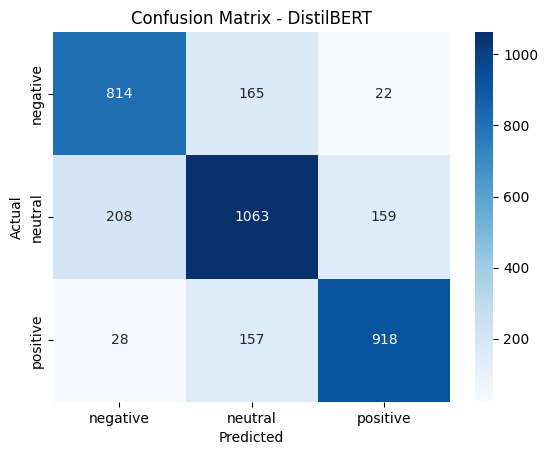

In [19]:
y_test_encoded = le.transform(test_df['sentiment'])

print("Accuracy:", accuracy_score(y_test_encoded, test_preds))
print("\nClassification Report:")
print(classification_report(y_test_encoded, test_preds, target_names=le.classes_))

cm = confusion_matrix(y_test_encoded, test_preds)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - DistilBERT')
plt.show()

In [20]:
X_test_list = list(test_df['text'])

print("=== Example Predictions ===\n")
for i in range(5):
    true_label = le.classes_[y_test_encoded[i]]
    pred_label = le.classes_[test_preds[i]]
    status = "correct" if true_label == pred_label else "wrong"
    print(f"Text: {X_test_list[i][:80]}")
    print(f"True: {true_label} | Predicted: {pred_label} [{status}]")
    print()

=== Example Predictions ===

Text: Last session of the day  http://twitpic.com/67ezh
True: neutral | Predicted: neutral [correct]

Text:  Shanghai is also really exciting (precisely -- skyscrapers galore). Good tweeps
True: positive | Predicted: positive [correct]

Text: Recession hit Veronique Branquinho, she has to quit her company, such a shame!
True: negative | Predicted: negative [correct]

Text:  happy bday!
True: positive | Predicted: positive [correct]

Text:  http://twitpic.com/4w75p - I like it!!
True: positive | Predicted: positive [correct]



In [21]:
model.save_pretrained("sentiment_model")
tokenizer.save_pretrained("sentiment_model")
print("Model saved!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved!
